In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
from src.feature_selection import (
    calculate_mutual_information,
    plot_mutual_information,
    select_top_features,
    add_mandatory_features,
    create_selected_dataset
)

## Load Engineered Dataset

In [5]:
df = pd.read_parquet(project_root / 'data' / 'preprocessed' / 'train_engineered.parquet')

In [6]:
df.shape

(590540, 446)

In [7]:
df.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,addr1_freq,addr2_freq,DeviceInfo_freq,card1_tx_count,card1_amt_mean,card1_amt_std,card1_amt_max,card1_amt_min,addr1_tx_count,addr1_amt_mean
0,86400,4.241327,4,13926,361.0,150.0,1,142.0,1,315.0,...,23078,586187,471874,43,5.341552,1.046860,7.203510,3.555348,23078,4.430629
1,86401,3.401197,4,2755,404.0,150.0,2,102.0,1,325.0,...,42751,586187,471874,683,4.843062,0.969717,8.713784,2.397895,42751,4.560372
2,86469,4.094345,4,4663,490.0,150.0,4,166.0,2,330.0,...,26287,586187,471874,1108,4.264870,0.748148,6.902743,2.602690,26287,4.366002
3,86499,3.931826,4,18132,567.0,150.0,2,117.0,2,476.0,...,9478,586187,471874,4209,4.381763,0.832129,8.068090,1.945910,9478,4.447507
4,86506,3.931826,1,4497,514.0,150.0,2,102.0,1,420.0,...,3581,586187,9,18,4.376947,0.719091,5.303305,3.088767,3581,4.600883


## Check Target Distribution

In [9]:
TARGET = "isFraud"

df[TARGET].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

## Separate Features and Target

In [12]:
X = df.drop(columns=[TARGET])

y = df[TARGET]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (590540, 445)
Target: (590540,)


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
X_train.shape

(472432, 445)

In [19]:
X_test.shape

(118108, 445)

## Calculate Mutual Information

In [21]:
mi_df = calculate_mutual_information (
    X_train, y_train
)

mi_df.head(20)


[Feature 1] Calculating Mutual Information...
            Sampling 100000 rows for MI calculation...
            Features evaluated : 445
            Highest MI Score   : 0.043814
            Top Feature        : V258


,Feature,MI Score
0,V258,0.043814
1,V259,0.041521
2,V230,0.036831
3,V199,0.036707
4,V201,0.036664
5,V189,0.034757
6,V190,0.034413
7,V257,0.034101
8,V176,0.033892
9,V245,0.033797


## Visualize Top Features


[Feature 2] Plotting Top 30 Features...


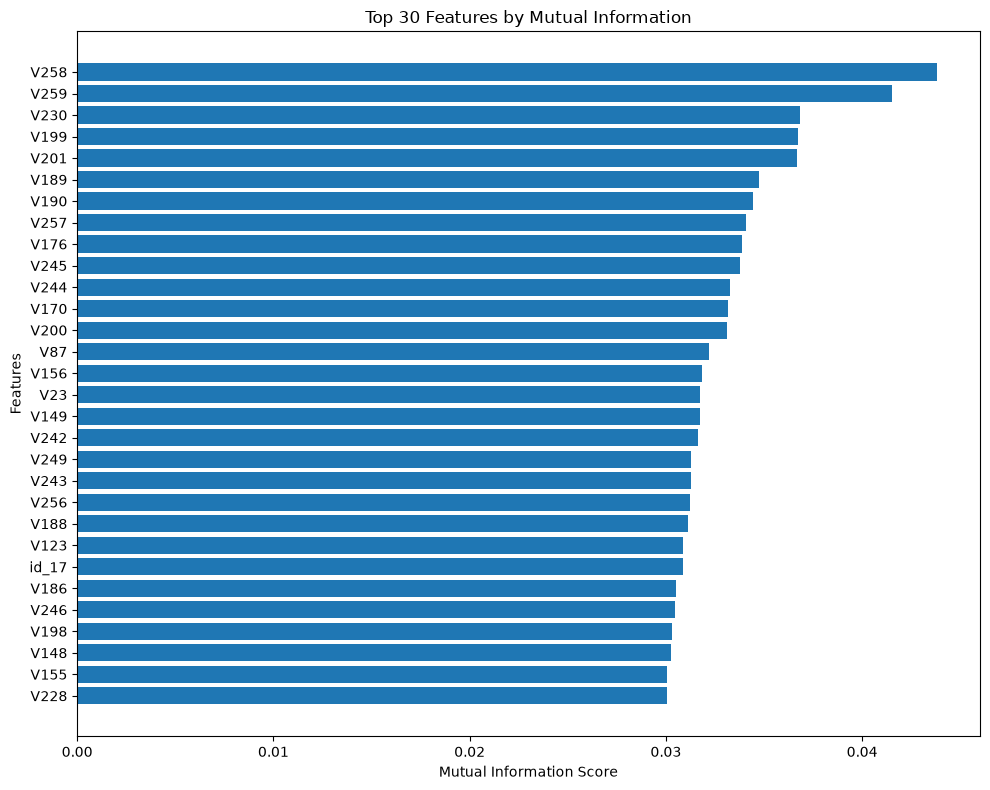

            Plot generated successfully.


In [22]:
plot_mutual_information(mi_df, top_n=30)

## Experiment with Top K

In [ ]:
top_30 = select_top_features(mi_df, top_k=30)

top_30[-20:-1]


[Feature 3] Selecting Top 30 Features...
            Features selected : 30
            First 5 features  : ['V258', 'V259', 'V230', 'V199', 'V201']


['V244',
 'V170',
 'V200',
 'V87',
 'V156',
 'V23',
 'V149',
 'V242',
 'V249',
 'V243',
 'V256',
 'V188',
 'V123',
 'id_17',
 'V186',
 'V246',
 'V198',
 'V148',
 'V155']

In [29]:
top_50 = select_top_features(mi_df, top_k=50)

top_50[-20:-1]


[Feature 3] Selecting Top 50 Features...
            Features selected : 50
            First 5 features  : ['V258', 'V259', 'V230', 'V199', 'V201']


['V255',
 'addr2',
 'V193',
 'V77',
 'V154',
 'V139',
 'DeviceInfo_freq',
 'R_email_freq',
 'V114',
 'V86',
 'V67',
 'V248',
 'id_36',
 'V153',
 'id_13',
 'M2',
 'V45',
 'V229',
 'id_19']

In [30]:
top_70 = select_top_features(mi_df, top_k=70)

top_70[-20:-1]


[Feature 3] Selecting Top 70 Features...
            Features selected : 70
            First 5 features  : ['V258', 'V259', 'V230', 'V199', 'V201']


['V3',
 'V252',
 'V222',
 'V47',
 'ProductCD',
 'V195',
 'V122',
 'V44',
 'V260',
 'V110',
 'D9',
 'M1',
 'V221',
 'V191',
 'V171',
 'V66',
 'V7',
 'id_35',
 'id_29']

## Deployment Features

In [31]:
mandatory_features = [

    "TransactionAmt",

    "ProductCD",

    "card1",

    "card4",

    "card6",

    "DeviceType",

    "tx_hour",

    "tx_day_of_week",

    "tx_is_weekend",

    "tx_is_night"

]

## Combine Features

In [32]:
final_features = add_mandatory_features(top_70, mandatory_features)


[Feature 4] Adding mandatory features...
            Mandatory features added : 8
            Final feature count       : 78


## Create Final Dataset

In [33]:
selected_df = create_selected_dataset(df, final_features)


[Feature 5] Creating selected dataset...
            Original shape : (590540, 446)
            Selected shape : (590540, 79)
            Features kept  : 78


## Check Final Features

In [35]:
selected_df.columns.tolist()

['TransactionAmt',
 'ProductCD',
 'card1',
 'card4',
 'card6',
 'DeviceType',
 'tx_hour',
 'tx_day_of_week',
 'tx_is_weekend',
 'tx_is_night',
 'V258',
 'V259',
 'V230',
 'V199',
 'V201',
 'V189',
 'V190',
 'V257',
 'V176',
 'V245',
 'V244',
 'V170',
 'V200',
 'V87',
 'V156',
 'V23',
 'V149',
 'V242',
 'V249',
 'V243',
 'V256',
 'V188',
 'V123',
 'id_17',
 'V186',
 'V246',
 'V198',
 'V148',
 'V155',
 'V228',
 'V255',
 'addr2',
 'V193',
 'V77',
 'V154',
 'V139',
 'DeviceInfo_freq',
 'R_email_freq',
 'V114',
 'V86',
 'V67',
 'V248',
 'id_36',
 'V153',
 'id_13',
 'M2',
 'V45',
 'V229',
 'id_19',
 'V3',
 'V252',
 'V222',
 'V47',
 'V195',
 'V122',
 'V44',
 'V260',
 'V110',
 'D9',
 'M1',
 'V221',
 'V191',
 'V171',
 'V66',
 'V7',
 'id_35',
 'id_29',
 'id_20',
 'isFraud']

## Save Dataset

In [37]:
output_path = (
    project_root /
    "data" /
    "preprocessed" /
    "train_selected.parquet"
)


selected_df.to_parquet(
    output_path,
    index=False
)


print(output_path)

d:\Projects\credit-card-fraud-detection\data\preprocessed\train_selected.parquet
